Problem Statement:
The increasing volume of unsolicited emails, commonly known as spam, poses
a significant challenge for email users and organizations. Spam emails not only
clutter inboxes but also pose security risks and undermine productivity. To
address this issue, there is a need to develop an effective email spam
classifier system that can automatically identify and filter out spam emails from legitimate ones.

In [2]:
# importing the required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

In [3]:
%matplotlib inline

In [4]:
warnings.filterwarnings('ignore')

In [5]:
# getting the data
data=pd.read_csv('Downloads/emails.csv',skipinitialspace=True)

In [6]:
data.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [7]:
data.shape

(5172, 3002)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


In [9]:
data.dtypes

Email No.     object
the            int64
to             int64
ect            int64
and            int64
               ...  
military       int64
allowing       int64
ff             int64
dry            int64
Prediction     int64
Length: 3002, dtype: object

In [10]:
data.shape

(5172, 3002)

In [11]:
data.isnull().any()

Email No.     False
the           False
to            False
ect           False
and           False
              ...  
military      False
allowing      False
ff            False
dry           False
Prediction    False
Length: 3002, dtype: bool

In [12]:
data.duplicated().sum()

0

In [13]:
data.describe()

,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
count,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,...,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000
mean,6.640565,6.188128,5.143852,3.075599,3.124710,2.627030,55.517401,2.466551,2.024362,10.600155,...,0.005027,0.012568,0.010634,0.098028,0.004254,0.006574,0.004060,0.914733,0.006961,0.290023
std,11.745009,9.534576,14.101142,6.045970,4.680522,6.229845,87.574172,4.314444,6.967878,19.281892,...,0.105788,0.199682,0.116693,0.569532,0.096252,0.138908,0.072145,2.780203,0.098086,0.453817
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,12.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,3.000000,1.000000,1.000000,2.000000,1.000000,28.000000,1.000000,0.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,7.000000,4.000000,3.000000,4.000000,2.000000,62.250000,3.000000,1.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,210.000000,132.000000,344.000000,89.000000,47.000000,77.000000,1898.000000,70.000000,167.000000,223.000000,...,4.000000,7.000000,2.000000,12.000000,3.000000,4.000000,3.000000,114.000000,4.000000,1.000000


In [14]:
data.columns

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)

In [15]:
data.iloc[:10, 6:20]

,of,a,you,hou,in,on,is,this,enron,i,be,that,will,have
0,0,2,0,0,0,0,1,0,0,2,0,0,0,0
1,2,102,1,27,18,21,13,0,1,61,4,2,0,0
2,0,8,0,0,4,2,0,0,0,8,0,0,0,0
3,1,51,2,10,1,5,9,2,0,16,2,0,0,1
4,2,57,0,9,3,12,2,2,0,30,8,0,0,2
5,3,45,1,0,16,12,8,1,0,52,2,0,0,0
6,1,37,0,0,9,4,6,2,0,27,1,0,0,0
7,2,21,6,0,2,6,2,0,0,28,1,0,1,0
8,1,18,0,0,3,3,2,1,0,15,0,1,0,0
9,0,49,1,16,9,4,1,0,0,35,10,0,2,1


In [16]:
col=data.columns

In [17]:
col.nunique()

3002

In [18]:
col.duplicated().sum()

0

In [19]:
data.iloc[10:30,20:100].columns

Index(['with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from',
       'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're',
       'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know',
       'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu',
       'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price',
       'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would',
       'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they',
       'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th',
       'volume', 'mail', 'contract', 'which', 'month'],
      dtype='object')

In [20]:
data.groupby('Prediction').agg(count_make=('make','count'),countfw=('fw','count')).reset_index()

,Prediction,count_make,countfw
0,0,3672,3672
1,1,1500,1500


In [21]:
data.iloc[10:30,100:200].columns

Index(['more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec',
       'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their',
       'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other',
       'here', 'like', 'b', 'flow', 'net', 'following', 'p', 'production',
       'when', 'over', 'back', 'want', 'original', 'them', 'below', 'o',
       'ticket', 'c', 'he', 'could', 'make', 'inc', 'report', 'march',
       'contact', 'were', 'days', 'list', 'nomination', 'system', 'who',
       'april', 'number', 'sale', 'don', 'its', 'first', 'thanks', 'business',
       'help', 'per', 'through', 'july', 'forward', 'font', 'free', 'daily',
       'use', 'order', 'today', 'r', 'had', 'fw', 'set', 'plant', 'statements',
       'go', 'gary', 'oil', 'line', 'sales', 'w', 'effective', 'well',
       'tenaska', 'take', 'june', 'x', 'within', 'nbsp', 'she', 'how', 'north',
       'america', 'being', 'under'],
      dtype='object')

In [22]:
obj=data.select_dtypes(include='object')

In [23]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for i in obj:
    data[i]=encoder.fit_transform(data[i])

In [24]:
data.nunique()

Email No.     5172
the             90
to              72
ect             90
and             53
              ... 
military         4
allowing         3
ff              23
dry              4
Prediction       2
Length: 3002, dtype: int64

In [25]:
data=data.rename(columns={'Prediction':'nature'})

In [26]:
data['target'].value_counts()

0    5105
1      45
2       8
3       5
4       4
5       4
6       1
Name: target, dtype: int64

In [27]:
data['nature'].value_counts()

0    3672
1    1500
Name: nature, dtype: int64

In [28]:
data.groupby('nature').agg(count_tagt=('target','count')).reset_index()

,nature,count_tagt
0,0,3672
1,1,1500


In [29]:
data.groupby('target').agg(count_nature=('nature','count')).reset_index()

,target,count_nature
0,0,5105
1,1,45
2,2,8
3,3,5
4,4,4
5,5,4
6,6,1


In [30]:
y=data['nature']

In [31]:
# taking the counts of dependent values 
y.value_counts()

0    3672
1    1500
Name: nature, dtype: int64

In [32]:
# dropping dependent variable and uneffective feature
x=data.drop(['nature','Email No.'],axis=1)

In [33]:
# converting to numpy array
x_new=x.to_numpy()

In [34]:
x_new

array([[ 0,  0,  1, ...,  0,  0,  0],
       [ 8, 13, 24, ...,  0,  1,  0],
       [ 0,  0,  1, ...,  0,  0,  0],
       ...,
       [ 0,  0,  1, ...,  0,  0,  0],
       [ 2,  7,  1, ...,  0,  1,  0],
       [22, 24,  5, ...,  0,  0,  0]], dtype=int64)

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x_new,y,test_size=0.2,random_state=30)

In [37]:
from sklearn.naive_bayes import GaussianNB

In [38]:
model=GaussianNB()

In [39]:
model.fit(x_train,y_train)

GaussianNB()

In [40]:
pred=model.predict(x_test)

In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [42]:
accuracy_score(y_test,pred)*100

96.42512077294685

In [43]:
confusion_matrix(y_test,pred)

array([[708,  27],
       [ 10, 290]], dtype=int64)

In [44]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       735
           1       0.91      0.97      0.94       300

    accuracy                           0.96      1035
   macro avg       0.95      0.96      0.96      1035
weighted avg       0.97      0.96      0.96      1035



In [45]:
from sklearn.metrics import roc_curve,auc

In [46]:
fpr,tpr,threshold=roc_curve(y_test,pred)

In [47]:
roc_auc=auc(fpr,tpr)

In [48]:
roc_auc

0.9649659863945579

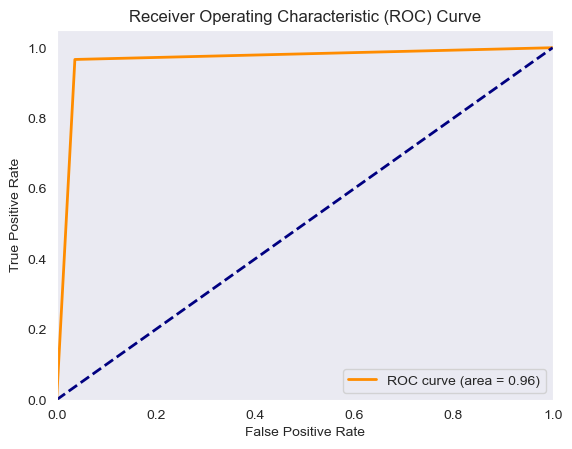

In [49]:
sns.set_style('dark')
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [50]:
# importing kfold,cross validation
from sklearn.model_selection import KFold,cross_val_score 

In [51]:
# initialising k-fold cross validation
k_folds=5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Performing K-Fold Cross-Validation
cv_scores = cross_val_score(model, x_new, y, cv=kf, scoring='accuracy')

# Printing the cross-validation scores
print("Cross-Validation Scores:", cv_scores)

# Calculating and printing the mean accuracy and standard deviation
# to know the average model performance and standard deviation on unseen data
mean_accuracy = cv_scores.mean()
std_deviation = cv_scores.std()
print("Mean Accuracy:", mean_accuracy)
print("Standard Deviation:", std_deviation)

Cross-Validation Scores: [0.94782609 0.95652174 0.94970986 0.95357834 0.95261122]
Mean Accuracy: 0.9520494491632328
Standard Deviation: 0.00303199285355098


The data is splitted into 5 folds and the accurracy score is calculated for each
following the mean accuracy of the splitted and computing the st-dev.
Overall,model seems to perform well,
with a high mean accuracy of 95% and a low standard deviation of 0.003,
indicating that it generalizes well to unseen data and is not
overly sensitive to the particular subsets of the data used for
training and validation during cross-validation.

In [52]:
# using Random Forest classifier

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
forest=RandomForestClassifier(n_estimators=50)

In [55]:
forest.fit(x_train,y_train)

RandomForestClassifier(n_estimators=50)

In [56]:
fpred=forest.predict(x_test)

In [57]:
print(f'random forest report\n{classification_report(y_test,fpred)}'.upper())

RANDOM FOREST REPORT
              PRECISION    RECALL  F1-SCORE   SUPPORT

           0       0.97      0.98      0.98       735
           1       0.96      0.92      0.94       300

    ACCURACY                           0.97      1035
   MACRO AVG       0.96      0.95      0.96      1035
WEIGHTED AVG       0.97      0.97      0.97      1035



In [58]:
k_folds=10
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Performing K-Fold Cross-Validation
cv_scores = cross_val_score(forest, x_new, y, cv=kf, scoring='accuracy')

# Printing the cross-validation scores
print("Cross-Validation Scores:", cv_scores *100)

# Calculating and printing the mean accuracy and standard deviation
# to know the average model performance and standard deviation on unseen data
mean_accuracy = cv_scores.mean()
std_deviation = cv_scores.std()
print("RandomForest Mean Accuracy:", mean_accuracy)
print("RandomForest Standard Deviation:", std_deviation)

Cross-Validation Scores: [96.33204633 96.91119691 97.09864603 98.06576402 96.13152805 97.29206963
 96.90522244 96.13152805 95.93810445 96.13152805]
RandomForest Mean Accuracy: 0.9669376339589105
RandomForest Standard Deviation: 0.006439304099351074


The mean accurracy of Randomforest is 96 percent while the dispersion is 0.006
which indicates generalization to unseen data but quiet higher than gaussian std which is 0.003 .

In [59]:
# using Decsion tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
tri=DecisionTreeClassifier()

In [62]:
tri.fit(x_train,y_train)

DecisionTreeClassifier()

In [63]:
tripred=tri.predict(x_test)

In [64]:
print(f'decision tree classifier report\n{classification_report(y_test,tripred)}'.upper())

DECISION TREE CLASSIFIER REPORT
              PRECISION    RECALL  F1-SCORE   SUPPORT

           0       0.94      0.96      0.95       735
           1       0.89      0.86      0.87       300

    ACCURACY                           0.93      1035
   MACRO AVG       0.92      0.91      0.91      1035
WEIGHTED AVG       0.93      0.93      0.93      1035



In [65]:
# confusion matrix for decision tree
confusion_matrix(y_test,tripred)

array([[703,  32],
       [ 43, 257]], dtype=int64)

In [66]:
trifpr,tritpr,threshold=roc_curve(y_test,tripred)

In [67]:
triroc_auc=auc(trifpr,tritpr)

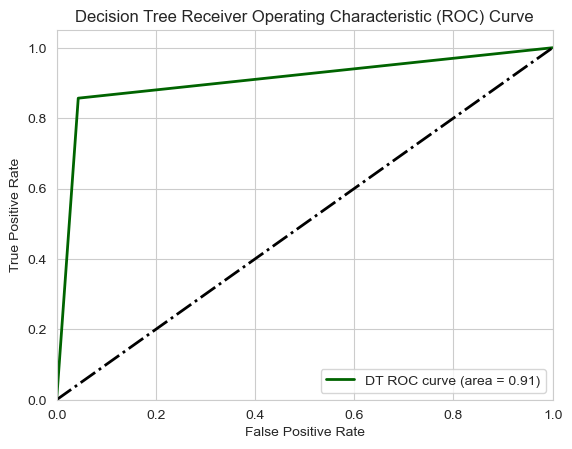

In [69]:
sns.set_style('whitegrid')
plt.figure()
plt.plot(trifpr, tritpr, color='darkgreen', lw=2, label='DT ROC curve (area = %0.2f)' % triroc_auc)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='-.')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()